# Classificação de Chamados de Suporte a partir de Texto (PLN)

Neste notebook, exploroamos o texto dos chamados de suporte técnico (`title` e `description`) e usamos para classificar o departamento responsável (`target_category`).

O percurso é: (1) pré-processamento de texto (tokenização, stopwords, stemming); (2) representações esparsas (Bag-of-Words e TF-IDF); (3) representação densa (camada de `Embedding`); (4) redução de dimensionalidade dos embeddings via PCA; e (5) um classificador MLP treinado **apenas** com esses embeddings reduzidos.

## 1. Preparação do ambiente

Monto o Google Drive (onde está o dataset `chamados.csv`), instalo as bibliotecas necessárias.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define the base path for Google Drive
drive_path = '/content/drive/MyDrive'

# Define the new directory path
new_path = os.path.join(drive_path, 'Projeto Integrador II', 'dataset')

# Create the directory if it doesn't exist
os.makedirs(new_path, exist_ok=True)

print(f"Directory created at: {new_path}")

Directory created at: /content/drive/MyDrive/Projeto Integrador II/dataset


In [ ]:
import sys
!{sys.executable} -m pip install -q nltk scikit-learn tensorflow numpy matplotlib pandas

import os
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

# Aumentar a largura máxima das colunas para exibir mais conteúdo nos displays de texto
pd.set_option('display.max_colwidth', None)

# Downloads necessários do NLTK (apenas o que é efetivamente usado no notebook)
for pkg in ['punkt', 'punkt_tab', 'stopwords']:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(f'Aviso: falha ao baixar {pkg}: {e}')

print('Ambiente configurado com sucesso!')

Ambiente configurado com sucesso!


## 2. Carregamento e exploração inicial dos dados

Carrego o dataset de chamados (`chamados.csv`) e inspeciono sua estrutura.

In [ ]:
csv_file_path = os.path.join(new_path, 'chamados.csv')
df = pd.read_csv(csv_file_path)
print("DataFrame 'df' loaded successfully with shape:", df.shape)
display(df.head())

DataFrame 'df' loaded successfully with shape: (5000, 44)


,ticket_id,created_at,customer_id,department,city_x,state_x,device_type,os,browser,network_type,...,vip,monthly_revenue,num_events,last_event_date,event_types,num_abertura,num_updates,num_encerramento,num_images_y,target_category
0,1,2025-01-01T00:17:00,5012,Operações,Campinas,BA,Desktop,Windows,Safari,WiFi,...,NaN,NaN,0,NaN,NaN,0,0,0,NaN,Hardware
1,2,2025-01-01T00:34:00,6574,Financeiro,Campinas,RJ,Notebook,Windows,Chrome,5G,...,NaN,NaN,0,NaN,NaN,0,0,0,NaN,RH
2,3,2025-01-01T00:51:00,2139,TI,Campinas,MG,Desktop,Linux,Chrome,5G,...,NaN,NaN,0,NaN,NaN,0,0,0,NaN,Financeiro
3,4,2025-01-01T01:08:00,7216,Financeiro,Belo Horizonte,RJ,Mobile,Android,Chrome,Cabo,...,NaN,NaN,0,NaN,NaN,0,0,0,NaN,Software
4,5,2025-01-01T01:25:00,5040,Financeiro,Belo Horizonte,PR,Mobile,iOS,Edge,Cabo,...,NaN,NaN,0,NaN,NaN,0,0,0,NaN,Rede


In [ ]:
# Capture the output of df.info()
info_buffer = io.StringIO()
df.info(buf=info_buffer)
info_output = info_buffer.getvalue()

print("Informações gerais do DataFrame 'df':")
print(info_output)

Informações gerais do DataFrame 'df':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_id              5000 non-null   int64  
 1   created_at             5000 non-null   object 
 2   customer_id            5000 non-null   int64  
 3   department             5000 non-null   object 
 4   city_x                 5000 non-null   object 
 5   state_x                5000 non-null   object 
 6   device_type            5000 non-null   object 
 7   os                     5000 non-null   object 
 8   browser                5000 non-null   object 
 9   network_type           5000 non-null   object 
 10  historical_tickets     5000 non-null   int64  
 11  sla_hours              5000 non-null   int64  
 12  resolution_time_hours  5000 non-null   int64  
 13  title                  5000 non-null   object 
 14  description       

## 3. Pré-processamento: tokenização, stopwords e stemming

Aplico tokenização de sentenças (`sent_tokenize`) e de palavras (`word_tokenize`) às colunas `title` e `description`, removo stopwords e aplico *stemming*, antes de vetorizar o texto.

In [ ]:
# Converter colunas 'title' e 'description' para string e preencher NaNs
df['title'] = df['title'].astype(str).fillna('')
df['description'] = df['description'].astype(str).fillna('')

# Tokenização de sentenças para 'title'
df['title_sentences'] = df['title'].apply(sent_tokenize)

# Tokenização de palavras para 'title'
df['title_words'] = df['title'].apply(word_tokenize)

# Tokenização de sentenças para 'description'
df['description_sentences'] = df['description'].apply(sent_tokenize)

# Tokenização de palavras para 'description'
df['description_words'] = df['description'].apply(word_tokenize)

# Carregar stop words em português
stop_words = set(stopwords.words('portuguese'))

# Inicializar SnowballStemmer para português
stemmer = SnowballStemmer('portuguese')

# Função para remover stop words e aplicar o stemming a uma lista de palavras
def remove_stopwords_and_stem(words):
    # Converter para minúsculas e remover caracteres não alfabéticos antes de verificar stop words
    filtered_words = [word for word in words if word.lower() not in stop_words and word.isalpha()]
    return [stemmer.stem(word) for word in filtered_words]

# Aplicar remoção de stop words e stemming às colunas tokenizadas
df['title_stemmed'] = df['title_words'].apply(remove_stopwords_and_stem)
df['description_stemmed'] = df['description_words'].apply(remove_stopwords_and_stem)

print("Colunas 'title_sentences', 'title_words', 'description_sentences', 'description_words', 'title_stemmed' e 'description_stemmed' criadas com sucesso, com remoção de stop words aplicada.")
display(df[['title', 'title_sentences', 'title_words', 'title_stemmed', 'description', 'description_sentences', 'description_words', 'description_stemmed']].head())

Colunas 'title_sentences', 'title_words', 'description_sentences', 'description_words', 'title_stemmed' e 'description_stemmed' criadas com sucesso, com remoção de stop words aplicada.


,title,title_sentences,title_words,title_stemmed,description,description_sentences,description_words,description_stemmed
0,Falha crítica no teclado: não funciona com tela preta.,[Falha crítica no teclado: não funciona com tela preta.],"[Falha, crítica, no, teclado, :, não, funciona, com, tela, preta, .]","[falh, crític, tecl, funcion, tel, pret]",Falha crítica no teclado: não funciona com tela preta.,[Falha crítica no teclado: não funciona com tela preta.],"[Falha, crítica, no, teclado, :, não, funciona, com, tela, preta, .]","[falh, crític, tecl, funcion, tel, pret]"
1,Falha no sistema de folha ao tentar gerar relatório.,[Falha no sistema de folha ao tentar gerar relatório.],"[Falha, no, sistema, de, folha, ao, tentar, gerar, relatório, .]","[falh, sistem, folh, tent, ger, relatóri]",Falha no sistema de folha ao tentar gerar relatório.,[Falha no sistema de folha ao tentar gerar relatório.],"[Falha, no, sistema, de, folha, ao, tentar, gerar, relatório, .]","[falh, sistem, folh, tent, ger, relatóri]"
2,O Sistema de tesouraria exibe cheiro de queimado ao gerar re...,[O Sistema de tesouraria exibe cheiro de queimado ao gerar re...],"[O, Sistema, de, tesouraria, exibe, cheiro, de, queimado, ao, gerar, re, ...]","[sistem, tesour, exib, cheir, queim, ger, re]",O Sistema de tesouraria exibe cheiro de queimado ao gerar relatório.,[O Sistema de tesouraria exibe cheiro de queimado ao gerar relatório.],"[O, Sistema, de, tesouraria, exibe, cheiro, de, queimado, ao, gerar, relatório, .]","[sistem, tesour, exib, cheir, queim, ger, relatóri]"
3,O aplicativo Sistema ERP fecha inesperadamente quando export...,[O aplicativo Sistema ERP fecha inesperadamente quando export...],"[O, aplicativo, Sistema, ERP, fecha, inesperadamente, quando, export, ...]","[aplic, sistem, erp, fech, inesper, export]",O aplicativo Sistema ERP fecha inesperadamente quando exportar dados.,[O aplicativo Sistema ERP fecha inesperadamente quando exportar dados.],"[O, aplicativo, Sistema, ERP, fecha, inesperadamente, quando, exportar, dados, .]","[aplic, sistem, erp, fech, inesper, export, dad]"
4,O acesso à banco de dados falha com reinicia sozinho.,[O acesso à banco de dados falha com reinicia sozinho.],"[O, acesso, à, banco, de, dados, falha, com, reinicia, sozinho, .]","[acess, banc, dad, falh, reinic, sozinh]",O acesso à banco de dados falha com reinicia sozinho.,[O acesso à banco de dados falha com reinicia sozinho.],"[O, acesso, à, banco, de, dados, falha, com, reinicia, sozinho, .]","[acess, banc, dad, falh, reinic, sozinh]"


## 4. Representação esparsa: Bag-of-Words e TF-IDF

Com o texto já normalizado (stemmed), construo duas representações esparsas: contagem de palavras (Bag-of-Words) e TF-IDF. Gero visualizações.

Shape da matriz BoW para 'title_stemmed': (5000, 201)
Shape da matriz TF-IDF para 'title_stemmed': (5000, 201)
Shape da matriz BoW para 'description_stemmed': (5000, 112)
Shape da matriz TF-IDF para 'description_stemmed': (5000, 112)

As matrizes BoW e TF-IDF foram geradas com sucesso.
Elas são armazenadas como matrizes esparsas, otimizadas para manipulação eficiente.


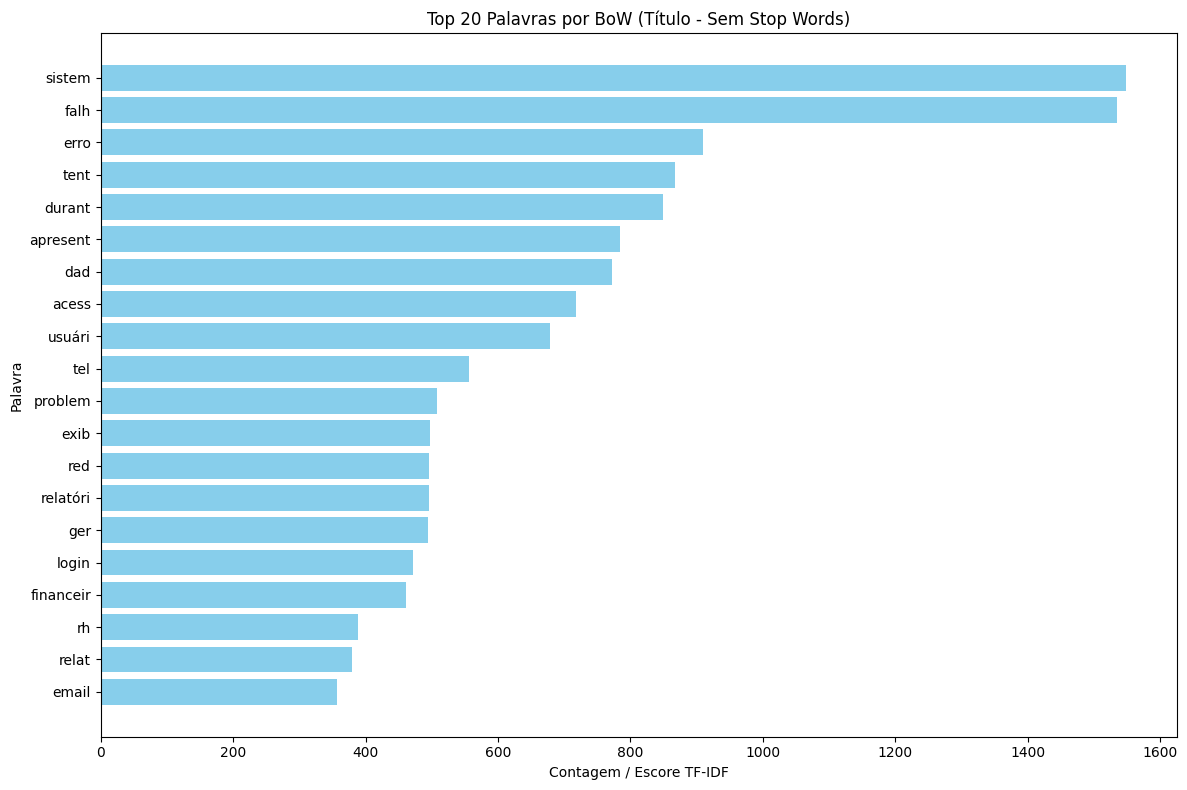

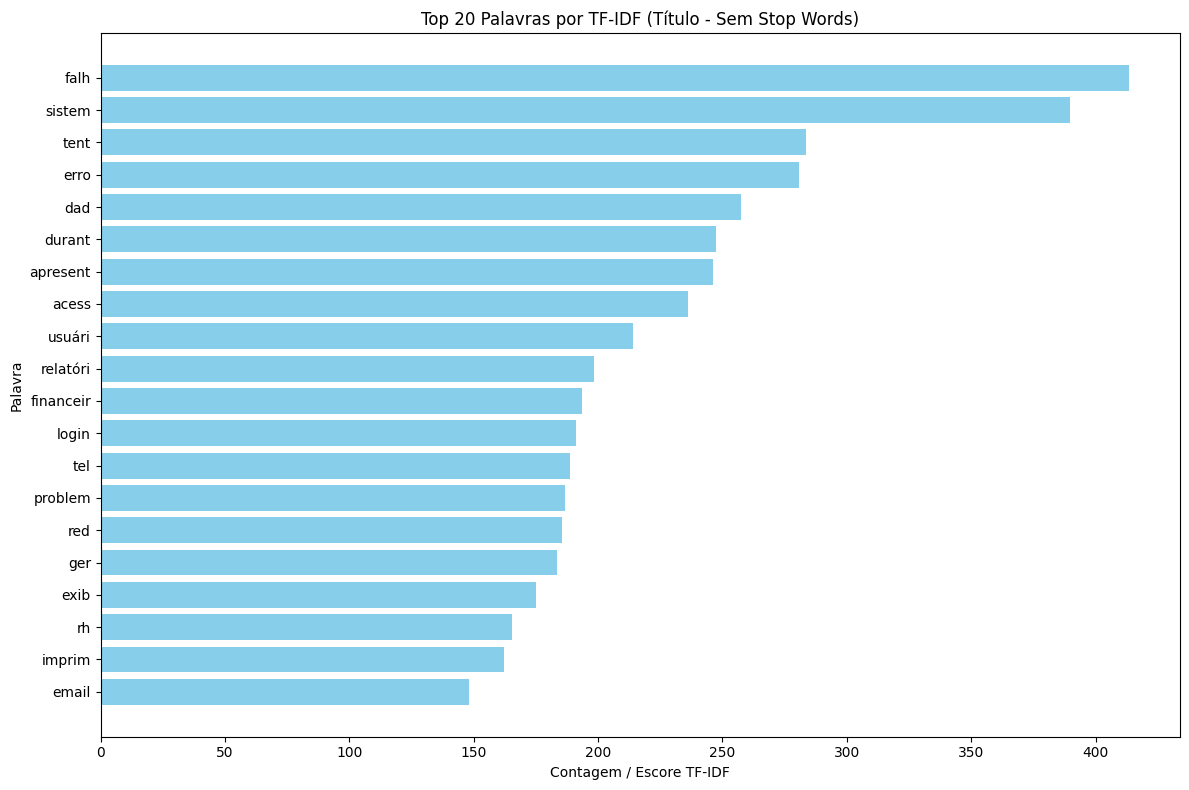

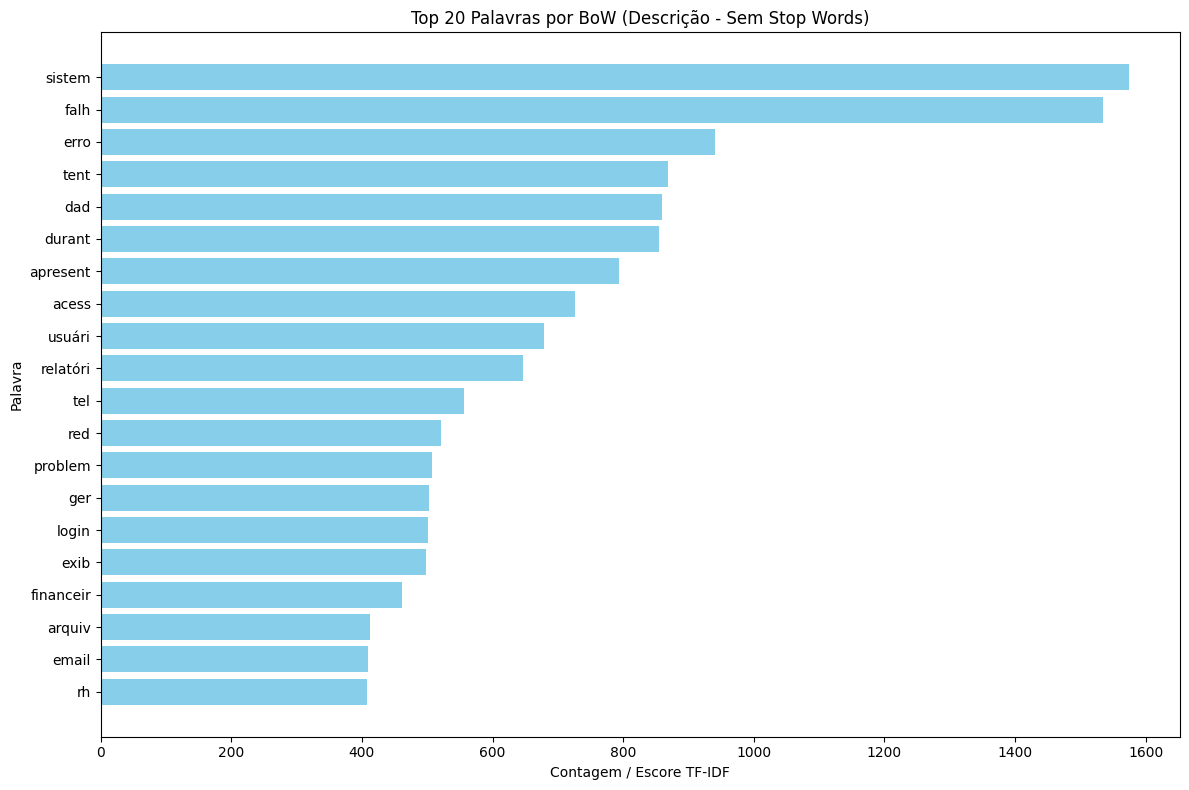

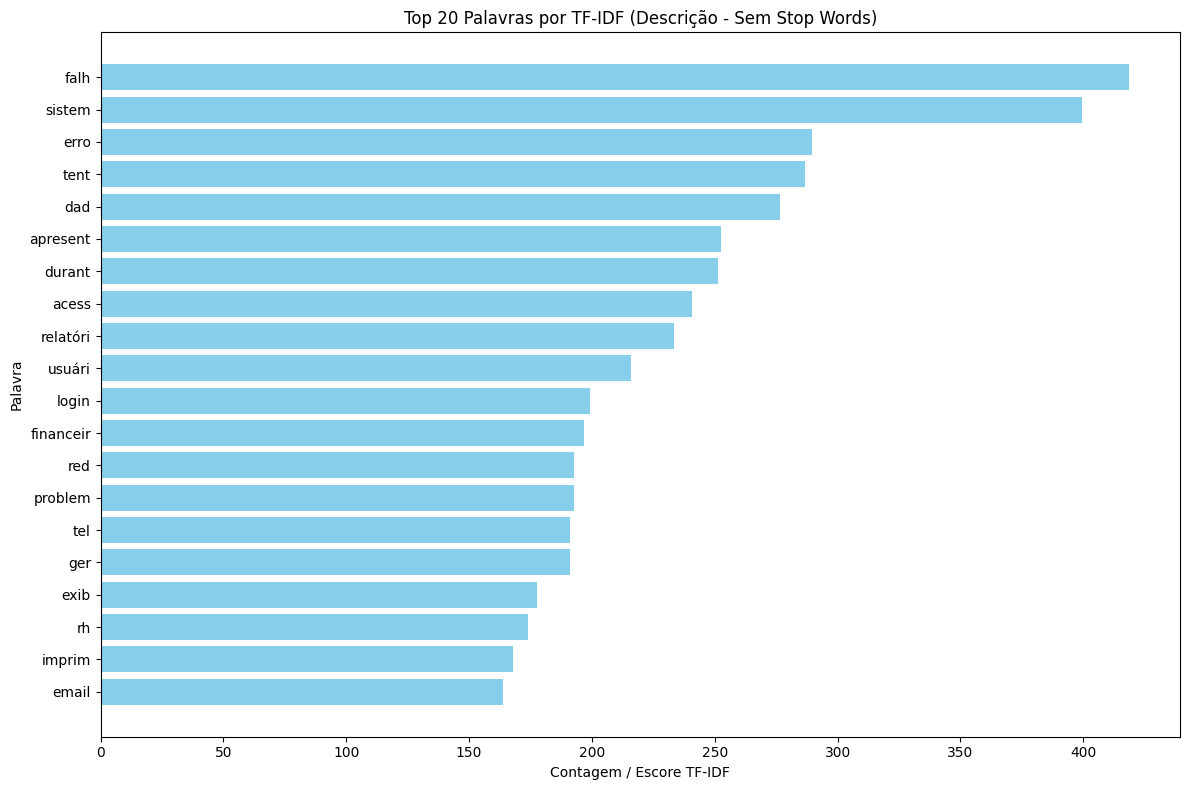


Visualizações das palavras mais frequentes (BoW) e com maiores escores TF-IDF foram geradas (com remoção de stop words).


In [ ]:
# Converter as listas de palavras stemmed de volta para strings para vectorização
df['title_stemmed_str'] = df['title_stemmed'].apply(lambda x: ' '.join(x))
df['description_stemmed_str'] = df['description_stemmed'].apply(lambda x: ' '.join(x))

# --- Para 'title_stemmed' ---
title_count_vectorizer = CountVectorizer()
bow_title = title_count_vectorizer.fit_transform(df['title_stemmed_str'])
title_tfidf_vectorizer = TfidfVectorizer()
tfidf_title = title_tfidf_vectorizer.fit_transform(df['title_stemmed_str'])

# --- Para 'description_stemmed' ---
description_count_vectorizer = CountVectorizer()
bow_description = description_count_vectorizer.fit_transform(df['description_stemmed_str'])
description_tfidf_vectorizer = TfidfVectorizer()
tfidf_description = description_tfidf_vectorizer.fit_transform(df['description_stemmed_str'])

print(f"Shape da matriz BoW para 'title_stemmed': {bow_title.shape}")
print(f"Shape da matriz TF-IDF para 'title_stemmed': {tfidf_title.shape}")
print(f"Shape da matriz BoW para 'description_stemmed': {bow_description.shape}")
print(f"Shape da matriz TF-IDF para 'description_stemmed': {tfidf_description.shape}")

print("\nAs matrizes BoW e TF-IDF foram geradas com sucesso.")
print("Elas são armazenadas como matrizes esparsas, otimizadas para manipulação eficiente.")

# --- Visualização ---

def plot_top_words(vectorizer, feature_matrix, title_prefix, n_top_words=20):
    feature_names = vectorizer.get_feature_names_out()
    sums = feature_matrix.sum(axis=0)

    # Convert to 1D array
    if isinstance(sums, np.matrix):
        word_counts = sums.tolist()[0]
    elif isinstance(sums, np.ndarray):
        word_counts = sums.flatten()
    else:
        word_counts = sums

    words_df = pd.DataFrame({'word': feature_names, 'count': word_counts})
    words_df = words_df.sort_values('count', ascending=False).head(n_top_words)

    plt.figure(figsize=(12, 8))
    plt.barh(words_df['word'][::-1], words_df['count'][::-1], color='skyblue')
    plt.xlabel('Contagem / Escore TF-IDF')
    plt.ylabel('Palavra')
    plt.title(f'Top {n_top_words} Palavras por {title_prefix}')
    plt.tight_layout()
    plt.show()

# Visualizar Top N palavras para BoW e TF-IDF dos títulos
plot_top_words(title_count_vectorizer, bow_title, 'BoW (Título - Sem Stop Words)')
plot_top_words(title_tfidf_vectorizer, tfidf_title, 'TF-IDF (Título - Sem Stop Words)')

# Visualizar Top N palavras para BoW e TF-IDF das descrições
plot_top_words(description_count_vectorizer, bow_description, 'BoW (Descrição - Sem Stop Words)')
plot_top_words(description_tfidf_vectorizer, tfidf_description, 'TF-IDF (Descrição - Sem Stop Words)')

print("\nVisualizações das palavras mais frequentes (BoW) e com maiores escores TF-IDF foram geradas (com remoção de stop words).")


**Leitura:** a frequência/relevância dos termos é bastante concentrada em um pequeno conjunto de palavras. Isso é esperado, já que os chamados têm termos técnicos bastante comuns entre si.

## 5. Similaridade de cosseno com TF-IDF

Uso a similaridade de cosseno para medir o quão parecidos são os chamados entre si, com base apenas no vocabulário que compartilham. Visualizo essa similaridade com heatmap.

Calculando similaridade de cosseno para títulos (TF-IDF)...
Shape da matriz de similaridade de cosseno para títulos: (5000, 5000)
Calculando similaridade de cosseno para descrições (TF-IDF)...
Shape da matriz de similaridade de cosseno para descrições: (5000, 5000)

Similaridades de cosseno calculadas com sucesso.

Gerando heatmaps para os primeiros 50 documentos...


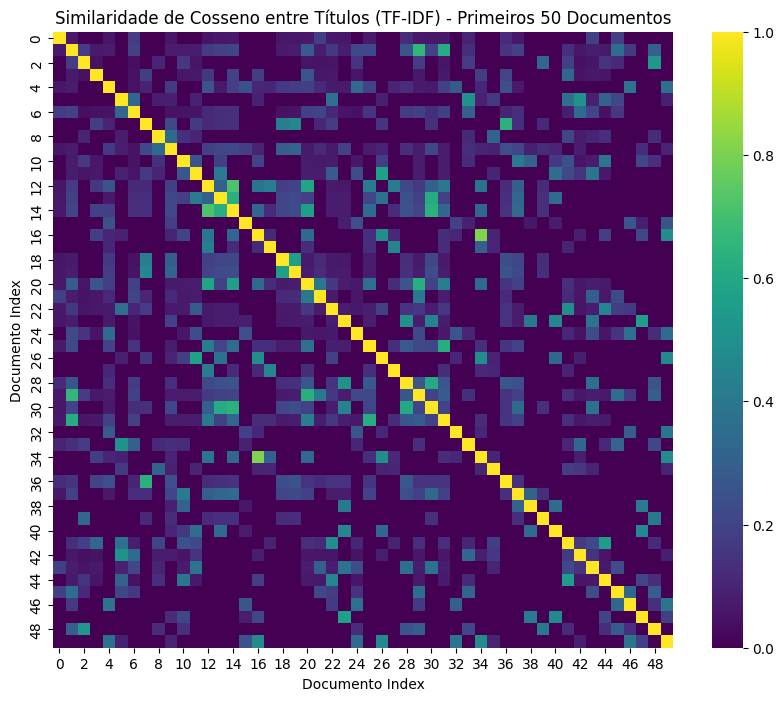

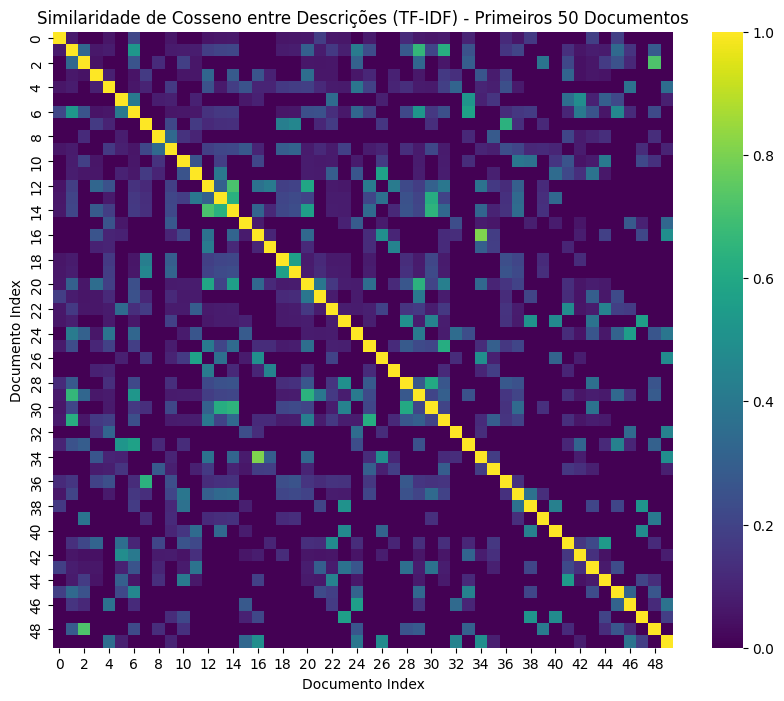

Análise de similaridade de cosseno concluída.


In [ ]:
# --- 1. Calcular Similaridade de Cosseno para Títulos (TF-IDF) ---
print("Calculando similaridade de cosseno para títulos (TF-IDF)...")
cosine_sim_title = cosine_similarity(tfidf_title)
print(f"Shape da matriz de similaridade de cosseno para títulos: {cosine_sim_title.shape}")

# --- 2. Calcular Similaridade de Cosseno para Descrições (TF-IDF) ---
print("Calculando similaridade de cosseno para descrições (TF-IDF)...")
cosine_sim_description = cosine_similarity(tfidf_description)
print(f"Shape da matriz de similaridade de cosseno para descrições: {cosine_sim_description.shape}")

print("\nSimilaridades de cosseno calculadas com sucesso.")

# --- 3. Visualizar Similaridade de Cosseno para um Subconjunto de Documentos ---
n_docs_to_visualize = 50 # Número de documentos para visualizar no heatmap

if n_docs_to_visualize > 0:
    print(f"\nGerando heatmaps para os primeiros {n_docs_to_visualize} documentos...")

    # Heatmap para Títulos
    plt.figure(figsize=(10, 8))
    sns.heatmap(cosine_sim_title[:n_docs_to_visualize, :n_docs_to_visualize], cmap='viridis', annot=False, fmt=".2f")
    plt.title(f'Similaridade de Cosseno entre Títulos (TF-IDF) - Primeiros {n_docs_to_visualize} Documentos')
    plt.xlabel('Documento Index')
    plt.ylabel('Documento Index')
    plt.show()

    # Heatmap para Descrições
    plt.figure(figsize=(10, 8))
    sns.heatmap(cosine_sim_description[:n_docs_to_visualize, :n_docs_to_visualize], cmap='viridis', annot=False, fmt=".2f")
    plt.title(f'Similaridade de Cosseno entre Descrições (TF-IDF) - Primeiros {n_docs_to_visualize} Documentos')
    plt.xlabel('Documento Index')
    plt.ylabel('Documento Index')
    plt.show()
else:
    print("Nenhum heatmap será gerado, pois 'n_docs_to_visualize' é 0.")

print("Análise de similaridade de cosseno concluída.")

**Leitura:** como a representação TF-IDF é esparsa, é de se esperar que as corrlações entre os chamados seja baixa. Por isso, seria melhor usar uma representação mais densa.

## 6. Representação densa (Embedding)

Como alternativa, treino uma camada `Embedding` (dimensão 100) para título e outra para descrição, convertendo cada palavra em um vetor denso. Depois, uso o `GlobalAveragePooling1D` para agregar os vetores das palavras de cada chamado em um único vetor de documento de tamanho fixo. Ao final, temos um vetor de tamanho 100 para cada chamado. Repito a análise de similaridade de cosseno com esses embeddings.

Comprimento máximo da sequência de títulos: 8
Comprimento máximo da sequência de descrições: 9
Shape das sequências de títulos preenchidas: (5000, 8)
Shape das sequências de descrições preenchidas: (5000, 9)

Resumo do modelo de Embedding para Títulos:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Gerando embeddings para títulos...
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Shape dos embeddings de títulos: (5000, 100)
Gerando embeddings para descrições...
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Shape dos embeddings de descrições: (5000, 100)

Calculando similaridade de cosseno com os novos embeddings...
Shape da matriz de similaridade de cosseno (embeddings de títulos): (5000, 5000)
Shape da matriz de similaridade de cosseno (embeddings de descrições): (5000, 5000)

Gerando heatmaps para os primeiros 50 documentos (embeddings)...



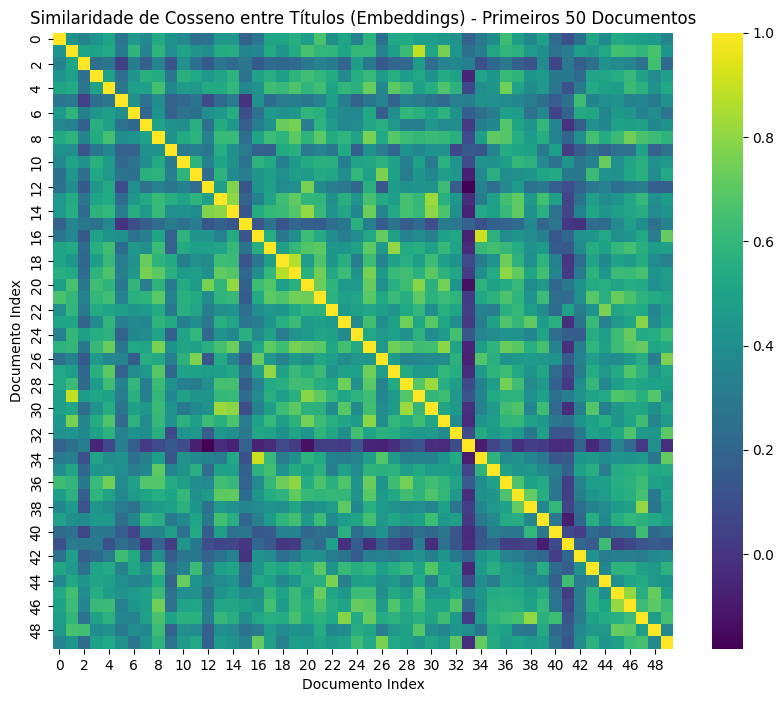

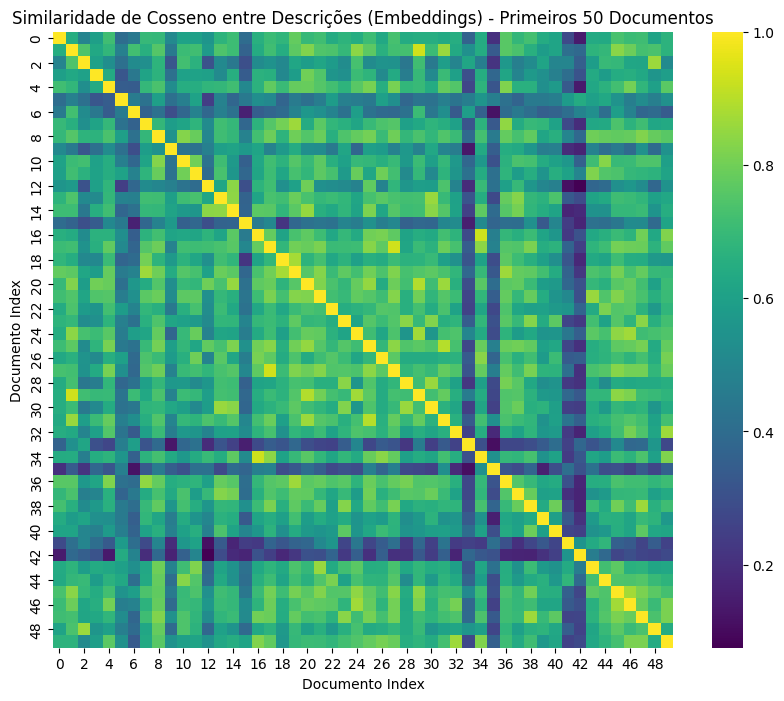

Análise de similaridade de cosseno com embeddings concluída.


In [ ]:
# 1. Preparar dados para a Camada de Embedding
# Criar mapeamento de palavra para índice para títulos (o +1 é para a indexação começar em 1, reservando 0 para padding/palavras desconhecidas)
title_word_index = {word: idx + 1 for idx, word in enumerate(title_count_vectorizer.get_feature_names_out())}
description_word_index = {word: idx + 1 for idx, word in enumerate(description_count_vectorizer.get_feature_names_out())}

# Converter texto para sequências de inteiros
title_sequences = [[title_word_index.get(word, 0) for word in text.split()] for text in df['title_stemmed_str']]
description_sequences = [[description_word_index.get(word, 0) for word in text.split()] for text in df['description_stemmed_str']]

# Determinar comprimento máximo para padding
# Garantir que max_len não seja 0 se houver sequências vazias após a tokenização
max_title_len = max(len(seq) for seq in title_sequences) if title_sequences else 1
max_description_len = max(len(seq) for seq in description_sequences) if description_sequences else 1

# Aplicar padding às sequências
padded_title_sequences = pad_sequences(title_sequences, maxlen=max_title_len, padding='post', truncating='post')
padded_description_sequences = pad_sequences(description_sequences, maxlen=max_description_len, padding='post', truncating='post')

print(f"Comprimento máximo da sequência de títulos: {max_title_len}")
print(f"Comprimento máximo da sequência de descrições: {max_description_len}")
print(f"Shape das sequências de títulos preenchidas: {padded_title_sequences.shape}")
print(f"Shape das sequências de descrições preenchidas: {padded_description_sequences.shape}")

# 2. Definir um modelo simples com uma Camada de Embedding
vocab_size_title = len(title_word_index) + 1 # +1 para o índice 0 (padding/palavras desconhecidas)
vocab_size_description = len(description_word_index) + 1
embedding_dim = 100 # Dimensão dos vetores de embedding

# Modelo de Embedding para títulos
title_embedding_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size_title, output_dim=embedding_dim, input_length=max_title_len),
    tf.keras.layers.GlobalAveragePooling1D() # Para obter um embedding de documento de tamanho fixo
])

# Modelo de Embedding para descrições
description_embedding_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size_description, output_dim=embedding_dim, input_length=max_description_len),
    tf.keras.layers.GlobalAveragePooling1D() # Para obter um embedding de documento de tamanho fixo
])

print("\nResumo do modelo de Embedding para Títulos:")
title_embedding_model.summary()
print("\nResumo do modelo de Embedding para Descrições:")
description_embedding_model.summary()

# 3. Gerar Embeddings
print("\nGerando embeddings para títulos...")
title_embeddings = title_embedding_model.predict(padded_title_sequences)
print(f"Shape dos embeddings de títulos: {title_embeddings.shape}")

print("Gerando embeddings para descrições...")
description_embeddings = description_embedding_model.predict(padded_description_sequences)
print(f"Shape dos embeddings de descrições: {description_embeddings.shape}")

# 4. Calcular Similaridade de Cosseno com os novos embeddings
print("\nCalculando similaridade de cosseno com os novos embeddings...")
cosine_sim_title_emb = cosine_similarity(title_embeddings)
cosine_sim_description_emb = cosine_similarity(description_embeddings)

print(f"Shape da matriz de similaridade de cosseno (embeddings de títulos): {cosine_sim_title_emb.shape}")
print(f"Shape da matriz de similaridade de cosseno (embeddings de descrições): {cosine_sim_description_emb.shape}")

# 5. Visualizar Similaridade de Cosseno para um Subconjunto de Documentos (Embeddings)
n_docs_to_visualize = 50 # Número de documentos para visualizar no heatmap

if n_docs_to_visualize > 0:
    print(f"\nGerando heatmaps para os primeiros {n_docs_to_visualize} documentos (embeddings)...\n")

    # Heatmap para Títulos (Embeddings)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cosine_sim_title_emb[:n_docs_to_visualize, :n_docs_to_visualize], cmap='viridis', annot=False, fmt=".2f")
    plt.title(f'Similaridade de Cosseno entre Títulos (Embeddings) - Primeiros {n_docs_to_visualize} Documentos')
    plt.xlabel('Documento Index')
    plt.ylabel('Documento Index')
    plt.show()

    # Heatmap para Descrições (Embeddings)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cosine_sim_description_emb[:n_docs_to_visualize, :n_docs_to_visualize], cmap='viridis', annot=False, fmt=".2f")
    plt.title(f'Similaridade de Cosseno entre Descrições (Embeddings) - Primeiros {n_docs_to_visualize} Documentos')
    plt.xlabel('Documento Index')
    plt.ylabel('Documento Index')
    plt.show()
else:
    print("Nenhum heatmap será gerado, pois 'n_docs_to_visualize' é 0.")

print("Análise de similaridade de cosseno com embeddings concluída.")

**Leitura:** com uma representação mais densa vemos na verdade que os chamados têm uma correlação maior entre si. Isso faz mais sentido: apesar de não compartilharem tentas palavras frequentes, o significado das descrições tem uma semelhança. Vamos usar esses significados para o modelo de classificação.

## 7. Preparando os embeddings para reuso: adicionando `ticket_id`

Transformo os embeddings em DataFrames e adiciono a coluna `ticket_id` como identificador único.

In [ ]:
# Monta os DataFrames de embeddings já com o ticket_id como identificador
df_title_embeddings = pd.DataFrame(
    title_embeddings,
    columns=[f'title_emb_{i}' for i in range(title_embeddings.shape[1])]
)
df_title_embeddings.insert(0, 'ticket_id', df['ticket_id'].values)

df_description_embeddings = pd.DataFrame(
    description_embeddings,
    columns=[f'desc_emb_{i}' for i in range(description_embeddings.shape[1])]
)
df_description_embeddings.insert(0, 'ticket_id', df['ticket_id'].values)

display(df_title_embeddings.head())
display(df_description_embeddings.head())

,ticket_id,title_emb_0,title_emb_1,title_emb_2,title_emb_3,title_emb_4,title_emb_5,title_emb_6,title_emb_7,title_emb_8,...,title_emb_90,title_emb_91,title_emb_92,title_emb_93,title_emb_94,title_emb_95,title_emb_96,title_emb_97,title_emb_98,title_emb_99
0,1,-0.025465,0.007559,0.013523,-0.028854,0.009470,0.004619,0.010255,0.017231,0.023742,...,0.004576,-0.010298,0.002786,-0.006965,0.000349,-0.012966,0.017304,-0.030585,-0.021410,0.010218
1,2,-0.001833,0.012475,0.013980,-0.020524,-0.016290,0.005411,0.017185,0.007161,0.007345,...,0.011747,-0.006911,-0.012475,0.001206,0.021038,-0.009310,0.016230,-0.006700,0.003657,0.012349
2,3,-0.000482,0.021235,0.002622,-0.011902,-0.000364,0.006229,0.006807,-0.002173,-0.001990,...,0.012257,-0.001512,0.002238,-0.003576,0.010567,0.001297,0.015161,-0.002836,-0.004355,0.014330
3,4,-0.016381,0.001858,0.000268,-0.032618,0.009801,0.026664,0.008247,-0.004278,0.013690,...,0.005391,0.003336,-0.012521,0.006500,0.006015,0.001348,0.004605,0.000890,-0.000115,0.002840
4,5,-0.021363,-0.012762,0.026906,-0.012607,0.003597,0.000652,0.018963,0.014042,0.012208,...,0.010919,0.007419,-0.012105,-0.015200,0.007793,-0.002448,0.006955,-0.011748,0.012826,0.009108


,ticket_id,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,...,desc_emb_90,desc_emb_91,desc_emb_92,desc_emb_93,desc_emb_94,desc_emb_95,desc_emb_96,desc_emb_97,desc_emb_98,desc_emb_99
0,1,0.020547,-0.004636,0.015778,-0.003695,0.004224,-0.022210,-0.003788,0.018057,0.004976,...,-0.010526,-0.007719,-0.001128,0.014131,-0.012896,0.012126,0.004909,0.017343,-0.009548,0.009093
1,2,0.008148,-0.006219,0.004266,0.007034,0.008634,-0.017098,0.019049,0.003366,-0.002822,...,-0.005537,0.000652,-0.001581,0.004203,-0.005338,0.019573,0.001913,-0.001950,-0.019571,0.009831
2,3,0.018486,-0.004412,0.003251,0.001020,0.019659,-0.013452,0.018115,0.007526,-0.002743,...,-0.002344,-0.009923,0.004645,0.009291,0.009220,0.010490,0.003324,0.001639,-0.005446,0.013485
3,4,0.021666,-0.001921,-0.001797,0.005332,0.004312,-0.017260,-0.003528,-0.003690,0.007081,...,-0.001106,-0.005989,-0.014727,0.000858,-0.000119,0.006561,0.016264,0.013218,0.001623,-0.005866
4,5,0.017690,-0.005024,0.004182,0.003618,0.009751,-0.009299,0.015117,0.005832,-0.001471,...,-0.008472,-0.005827,-0.007984,0.017018,-0.001657,0.007400,0.019023,0.010371,-0.006191,-0.002872


## 8. Redução de dimensionalidade com PCA

Os embeddings dos chamados têm 100 dimensões cada (título e descrição), mas boa parte dessa dimensionalidade é redundante. Aplico PCA, mantendo o número de componentes necessário para explicar 80% da variância dos dados. Isso reduziu o título de 100 para 22 dimensões e a descrição de 100 para 21 — preservando a maior parte da informação relevante.

[Título] Dimensão original: 100
[Título] Dimensão após PCA (80% da variância): 23


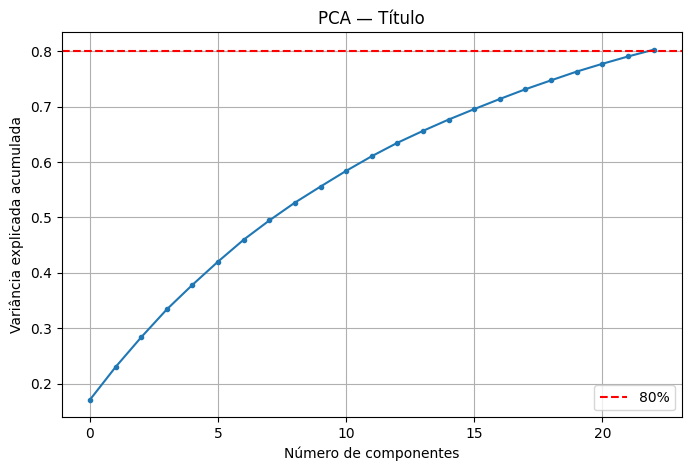

[Descrição] Dimensão original: 100
[Descrição] Dimensão após PCA (80% da variância): 21


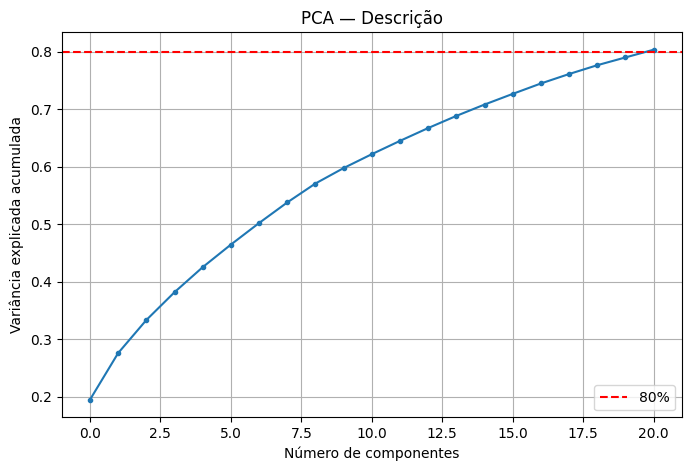

In [ ]:
def aplicar_pca(embeddings, nome, variancia_desejada=0.80):
    # PCA com número de componentes que preserva a variância desejada
    pca = PCA(n_components=variancia_desejada, svd_solver='full', random_state=42)
    embeddings_reduzidos = pca.fit_transform(embeddings)

    print(f"[{nome}] Dimensão original: {embeddings.shape[1]}")
    print(f"[{nome}] Dimensão após PCA ({variancia_desejada*100:.0f}% da variância): {embeddings_reduzidos.shape[1]}")

    # Curva de variância explicada acumulada
    plt.figure(figsize=(8, 5))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', markersize=3)
    plt.axhline(y=variancia_desejada, color='r', linestyle='--', label=f'{variancia_desejada*100:.0f}%')
    plt.xlabel('Número de componentes')
    plt.ylabel('Variância explicada acumulada')
    plt.title(f'PCA — {nome}')
    plt.legend()
    plt.grid(True)
    plt.show()

    return pca, embeddings_reduzidos

pca_title, title_embeddings_pca = aplicar_pca(title_embeddings, 'Título')
pca_description, description_embeddings_pca = aplicar_pca(description_embeddings, 'Descrição')

In [ ]:
df_title_embeddings_pca = pd.DataFrame(
    title_embeddings_pca,
    columns=[f'title_pca_{i}' for i in range(title_embeddings_pca.shape[1])]
)
df_title_embeddings_pca.insert(0, 'ticket_id', df['ticket_id'].values)

df_description_embeddings_pca = pd.DataFrame(
    description_embeddings_pca,
    columns=[f'desc_pca_{i}' for i in range(description_embeddings_pca.shape[1])]
)
df_description_embeddings_pca.insert(0, 'ticket_id', df['ticket_id'].values)

display(df_title_embeddings_pca.head())
display(df_description_embeddings_pca.head())

,ticket_id,title_pca_0,title_pca_1,title_pca_2,title_pca_3,title_pca_4,title_pca_5,title_pca_6,title_pca_7,title_pca_8,...,title_pca_13,title_pca_14,title_pca_15,title_pca_16,title_pca_17,title_pca_18,title_pca_19,title_pca_20,title_pca_21,title_pca_22
0,1,0.002668,0.015564,-0.006638,-0.019813,0.006385,0.000937,-0.003662,-0.009448,-0.022872,...,-0.007026,0.004904,0.015769,-0.003143,0.004115,-0.017131,0.009583,-0.010499,-0.011728,-0.028332
1,2,-0.017703,0.005710,-0.022030,-0.033141,0.020275,0.014457,-0.016962,-0.002727,0.010319,...,0.000392,-0.001088,-0.004190,0.004975,-0.006161,0.006751,-0.015606,0.003415,0.014995,0.004921
2,3,-0.046015,-0.010129,-0.031569,-0.027481,0.022844,-0.016836,0.002755,-0.002589,0.005158,...,0.005590,-0.004045,-0.010211,0.000399,0.000688,-0.002901,0.007613,-0.020752,0.017605,-0.004969
3,4,-0.004034,-0.004723,0.006109,-0.006082,-0.021021,-0.022660,0.002064,0.025265,-0.012396,...,0.003019,0.001678,0.011641,0.004096,-0.003285,0.005504,-0.005143,-0.003593,0.008314,-0.003755
4,5,0.007023,0.009679,0.004031,-0.026506,-0.008632,-0.014353,0.011167,0.010310,0.022532,...,-0.010652,0.020877,-0.008406,0.005876,0.009606,0.011288,0.015978,0.026850,0.001569,0.003672


,ticket_id,desc_pca_0,desc_pca_1,desc_pca_2,desc_pca_3,desc_pca_4,desc_pca_5,desc_pca_6,desc_pca_7,desc_pca_8,...,desc_pca_11,desc_pca_12,desc_pca_13,desc_pca_14,desc_pca_15,desc_pca_16,desc_pca_17,desc_pca_18,desc_pca_19,desc_pca_20
0,1,0.000365,0.020869,-0.016161,-0.000522,-0.008422,-0.017762,0.016197,0.007760,0.009410,...,-0.017470,-0.005078,0.013086,-0.001193,0.006914,-0.012694,-0.003187,0.005399,-0.014199,-0.005583
1,2,-0.002704,-0.016155,-0.036632,0.011334,0.001225,-0.003358,-0.012337,-0.016382,-0.005325,...,0.004464,-0.006186,-0.006365,0.004148,0.013972,0.011430,-0.003778,-0.022338,-0.004869,0.004612
2,3,0.028793,-0.027533,-0.022024,0.030224,0.018902,-0.008598,0.006828,0.009663,0.019457,...,-0.006424,-0.005496,-0.007802,0.008999,0.007368,0.009093,0.013609,0.013975,0.002071,-0.002410
3,4,0.028431,-0.002601,-0.017744,-0.005962,0.037051,0.003400,0.002883,0.021214,-0.010968,...,-0.010162,0.003669,0.015298,-0.001918,-0.014230,-0.005840,0.013967,-0.007924,0.012986,0.004810
4,5,-0.004371,0.011150,-0.023333,-0.034715,0.006009,0.009055,0.012560,0.005749,-0.001299,...,0.002730,-0.001160,-0.005358,0.006695,0.010352,-0.018645,0.016108,0.014494,-0.003792,-0.010425


## 9. Unindo os embeddings reduzidos ao dataset principal

Uso o `ticket_id` para unir as colunas de PCA de título e descrição de volta ao df principal.

In [ ]:
# Junta as versões reduzidas por PCA de volta ao df principal, usando ticket_id
df = df.merge(df_title_embeddings_pca, on='ticket_id', how='left')
df = df.merge(df_description_embeddings_pca, on='ticket_id', how='left')

print(f"Shape de df após o merge: {df.shape}")
display(df.head())

assert df.shape[0] == 5000, f"Esperado 5000 linhas, veio {df.shape[0]}"
assert df.filter(like='title_pca_').isnull().sum().sum() == 0, "Há tickets sem embedding de título"
assert df.filter(like='desc_pca_').isnull().sum().sum() == 0, "Há tickets sem embedding de descrição"
print("OK — merge íntegro, sem duplicatas ou nulos.")

Shape de df após o merge: (5000, 96)


,ticket_id,created_at,customer_id,department,city_x,state_x,device_type,os,browser,network_type,...,desc_pca_11,desc_pca_12,desc_pca_13,desc_pca_14,desc_pca_15,desc_pca_16,desc_pca_17,desc_pca_18,desc_pca_19,desc_pca_20
0,1,2025-01-01T00:17:00,5012,Operações,Campinas,BA,Desktop,Windows,Safari,WiFi,...,-0.017470,-0.005078,0.013086,-0.001193,0.006914,-0.012694,-0.003187,0.005399,-0.014199,-0.005583
1,2,2025-01-01T00:34:00,6574,Financeiro,Campinas,RJ,Notebook,Windows,Chrome,5G,...,0.004464,-0.006186,-0.006365,0.004148,0.013972,0.011430,-0.003778,-0.022338,-0.004869,0.004612
2,3,2025-01-01T00:51:00,2139,TI,Campinas,MG,Desktop,Linux,Chrome,5G,...,-0.006424,-0.005496,-0.007802,0.008999,0.007368,0.009093,0.013609,0.013975,0.002071,-0.002410
3,4,2025-01-01T01:08:00,7216,Financeiro,Belo Horizonte,RJ,Mobile,Android,Chrome,Cabo,...,-0.010162,0.003669,0.015298,-0.001918,-0.014230,-0.005840,0.013967,-0.007924,0.012986,0.004810
4,5,2025-01-01T01:25:00,5040,Financeiro,Belo Horizonte,PR,Mobile,iOS,Edge,Cabo,...,0.002730,-0.001160,-0.005358,0.006695,0.010352,-0.018645,0.016108,0.014494,-0.003792,-0.010425


OK — merge íntegro, sem duplicatas ou nulos.


## 10. Classificação com MLP usando apenas os embeddings textuais

Treino um classificador MLP para prever o departamento (`target_category`) usando **apenas** os embeddings reduzidos de título e descrição. Vamos comparar esses resultados com o que obtivemos usando as features que caracterizam o chamado (prioridade, dispositivo, tempo de resolução etc.).

In [ ]:
# Colunas de embeddings (PCA) já mergeadas no df
colunas_pca = [c for c in df.columns if c.startswith('title_pca_') or c.startswith('desc_pca_')]
print(f"{len(colunas_pca)} colunas de embeddings PCA")

# Rótulo
le = LabelEncoder()
y = le.fit_transform(df['target_category'])

44 colunas de embeddings PCA


### Divisão treino / validação / teste

Separo os dados em treino (80%), validação (10%) e teste (10%), estratificando pela classe (`target_category`) para preservar a proporção de cada departamento em todos os conjuntos.

In [ ]:
X_index = df.index.values

idx_treino_val, idx_teste = train_test_split(
    X_index, test_size=0.10, random_state=42, stratify=y
)
idx_treino, idx_val = train_test_split(
    idx_treino_val, test_size=0.111, random_state=42, stratify=y[idx_treino_val]
)  # 0.111 de 90% ≈ 10% do total

print(f"Treino: {len(idx_treino)} | Validação: {len(idx_val)} | Teste: {len(idx_teste)}")

Treino: 4000 | Validação: 500 | Teste: 500


### Arquitetura do MLP e treinamento

Uso a mesma arquitetura testada anteriormente com as variáveis tabulares (duas camadas ocultas de 128 e 64 neurônios, ativação ReLU, otimizador Adam, *early stopping*), para isolar o efeito da mudança de features — texto vs. tabular — sem também mudar a arquitetura. Como os componentes de PCA não estavam em nenhuma escala padronizada, aplico `StandardScaler` antes de treinar.

In [ ]:
X_emb_treino = df.loc[idx_treino, colunas_pca].values
X_emb_val    = df.loc[idx_val, colunas_pca].values
X_emb_teste  = df.loc[idx_teste, colunas_pca].values

scaler_emb = StandardScaler()
X_emb_treino_scaled = scaler_emb.fit_transform(X_emb_treino)
X_emb_val_scaled    = scaler_emb.transform(X_emb_val)
X_emb_teste_scaled  = scaler_emb.transform(X_emb_teste)

y_treino = y[idx_treino]
y_val    = y[idx_val]
y_teste  = y[idx_teste]

mlp_emb = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=200,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)
mlp_emb.fit(X_emb_treino_scaled, y_treino)

y_pred_emb = mlp_emb.predict(X_emb_teste_scaled)
print(f"\nAcurácia (só embeddings PCA): {accuracy_score(y_teste, y_pred_emb):.4f}")
print(classification_report(y_teste, y_pred_emb, target_names=le.classes_))

Iteration 1, loss = 1.59492138
Validation score: 0.690000
Iteration 2, loss = 1.04176694
Validation score: 0.815000
Iteration 3, loss = 0.62847953
Validation score: 0.862500
Iteration 4, loss = 0.38738558
Validation score: 0.892500
Iteration 5, loss = 0.26428922
Validation score: 0.915000
Iteration 6, loss = 0.19804854
Validation score: 0.927500
Iteration 7, loss = 0.15887741
Validation score: 0.930000
Iteration 8, loss = 0.12968547
Validation score: 0.937500
Iteration 9, loss = 0.11032160
Validation score: 0.950000
Iteration 10, loss = 0.09645100
Validation score: 0.947500
Iteration 11, loss = 0.08452380
Validation score: 0.947500
Iteration 12, loss = 0.07560801
Validation score: 0.955000
Iteration 13, loss = 0.06965033
Validation score: 0.955000
Iteration 14, loss = 0.06407433
Validation score: 0.947500
Iteration 15, loss = 0.06081218
Validation score: 0.952500
Iteration 16, loss = 0.05682569
Validation score: 0.955000
Iteration 17, loss = 0.05499422
Validation score: 0.962500
Iterat

## 11. Diagnóstico visual: curva de perda e matriz de confusão

Complemento a avaliação com a curva de perda durante o treinamento (para verificar a convergência) e a matriz de confusão no conjunto de teste, que detalha exatamente quais departamentos são confundidos entre si.

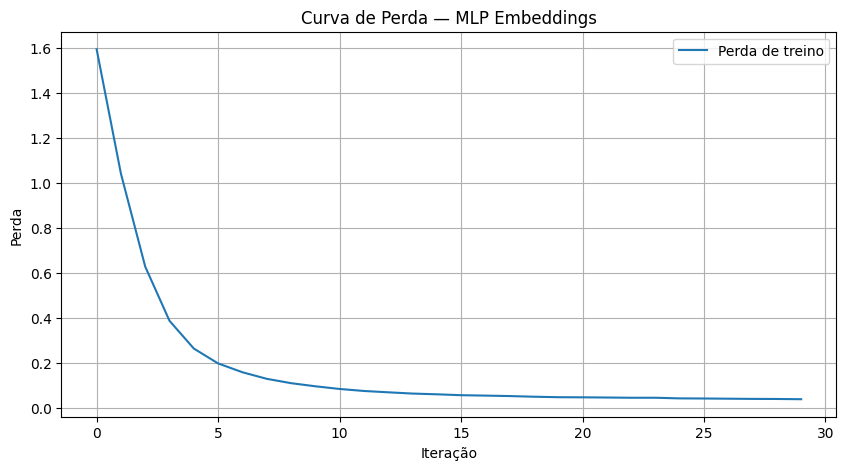

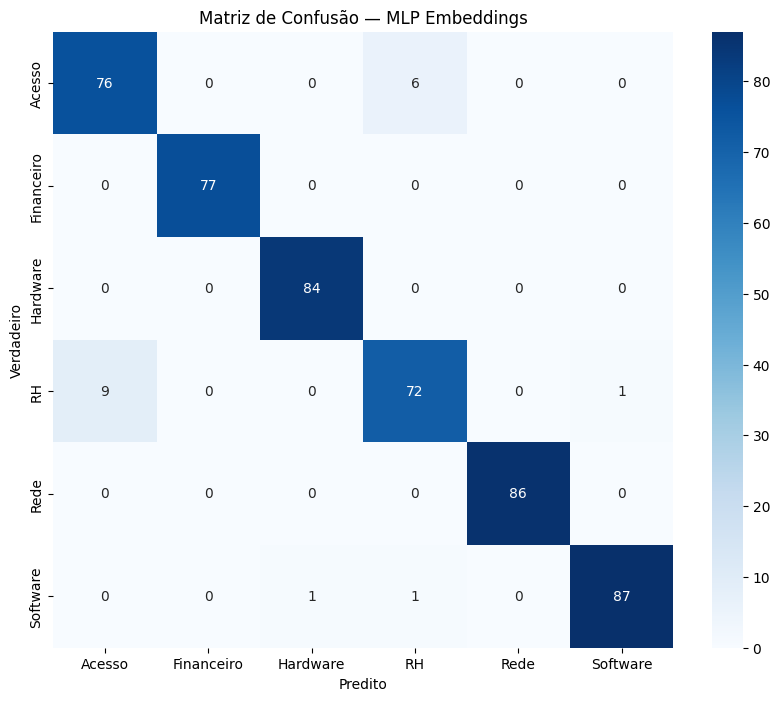

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(mlp_emb.loss_curve_, label='Perda de treino')
plt.xlabel('Iteração'); plt.ylabel('Perda'); plt.title('Curva de Perda — MLP Embeddings')
plt.grid(True); plt.legend(); plt.show()

cm = confusion_matrix(y_teste, y_pred_emb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predito'); plt.ylabel('Verdadeiro'); plt.title('Matriz de Confusão — MLP Embeddings')
plt.show()

### Resultado

O MLP treinado apenas com os embeddings textuais (título + descrição, reduzidos por PCA) atingiu **95,4% de acurácia** no conjunto de teste — um resultado bastante forte considerando que nenhuma variável tabular foi utilizada. Olhando o relatório por classe, o desempenho é quase perfeito em Financeiro, Hardware e Rede (precisão e recall ≥ 0,97), um pouco mais fraco em RH (recall de 0,83) e Acesso (precisão de 0,85). Os F1, que equilibram precisão e recall, são de 0,89 para cima.

De qualquer forma, esse modelo representa uma melhoria muito significativa e, relação à versão que utiliza apenas features dos chamados. O modelo anterior teve acurácia de 46.90% no conjunto, com a melhor classe alcançando 73% de acurácia e as piores nem chegaram a 40%.

